# The Price of Hedging
1. Below we first generate 2 random return series we will use in the homwork.
2. Compute some basic stats on the return streams, including annualized returns, volatilities, sharpes and correlations.
3. Combine the two returns streams optimally. What is the Sharpe ratio of the combo?
4. Now, compute what happens to the optimal weights and sharpes as we change the average annualized return on "HEDGE" in a range between -10% and 10% in increments of 1%. Roughly what return do you need on "HEDGE" to justify a zero weight? 


In [2]:
import numpy as np 
import pandas as pd 
def gen_strat_returns():
    np.random.seed(5)
    
    days = 252
    
    corr = [[1, -0.5],
            [-0.5, 1]]
    
    corr = np.array(corr)
    
    vols = np.diag(np.array([0.1, 0.1])) / np.sqrt(days)
    
    sigma = vols @ corr @ vols
    
    mu = np.array([0.1,0.1]) / days
    
    dates = pd.date_range('20100101','20191231',freq='B')
    
    rets = np.random.multivariate_normal(mu, sigma, size = len(dates))
    rets = pd.DataFrame(rets,columns = ['X','HEDGE'], index = dates)
    

    rets = rets/rets.std()*0.1/np.sqrt(days)
    rets = rets-rets.mean()
    rets = rets+mu
    return rets

returns = gen_strat_returns()
print(returns)

                   X     HEDGE
2010-01-01 -0.003186  0.001821
2010-01-04 -0.013704  0.012633
2010-01-05  0.004585  0.005928
2010-01-06  0.003306 -0.006154
2010-01-07 -0.001811  0.000476
...              ...       ...
2019-12-25 -0.002816  0.000228
2019-12-26 -0.000756  0.000144
2019-12-27 -0.003515 -0.007862
2019-12-30  0.009921 -0.005380
2019-12-31 -0.001754  0.001020

[2608 rows x 2 columns]


In [4]:
days = 252

statistics = {}

statistics['ret'] = returns.mean()*days
statistics['vol'] = returns.std()*np.sqrt(days)
statistics['sr'] = statistics['ret'] / statistics['vol']
statistics = pd.DataFrame(statistics)

statistics

,ret,vol,sr
X,0.1,0.1,1.0
HEDGE,0.1,0.1,1.0


In [5]:
returns.corr()

,X,HEDGE
X,1.000000,-0.513782
HEDGE,-0.513782,1.000000


In [6]:
days = 252
mu = returns.mean()
sigma = returns.cov()

def optimal_weights(sigma,mu):
    wgt = np.linalg.inv(sigma) @ mu 
    wgt = wgt / np.abs(wgt).sum()
    return wgt

wgt = optimal_weights(sigma,mu)
combo = (returns*wgt).sum(1)
combo.mean()/combo.std()*np.sqrt(days)

np.float64(2.0281480679441923)

In [8]:
days = 252
get_sharpe = lambda x: x.mean()/x.std()*np.sqrt(days)

wgts = {}
sharpes = {}

for hedge_ret in np.arange(-0.1,0.11,0.01):

    returns['HEDGE'] = returns['HEDGE'] - returns['HEDGE'].mean() + hedge_ret / days
    mu = returns.mean() 
    
    wgt = pd.Series(optimal_weights(sigma,mu),mu.index)
    
    hedge_ret_str = '%.0f%%'%(hedge_ret*100)
    wgts[hedge_ret_str] = wgt 
        
    sharpes[hedge_ret_str] = get_sharpe((returns*wgt).sum(1))
    
wgts = pd.DataFrame(wgts).T
sharpes = pd.Series(sharpes)

print(sharpes)

-10%    1.149432
-9%     1.096659
-8%     1.054183
-7%     1.023286
-6%     1.005037
-5%     1.000129
-4%     1.008756
-3%     1.030579
-2%     1.064787
-1%     1.110235
-0%     1.165609
1%      1.229569
2%      1.300850
3%      1.378315
4%      1.460981
5%      1.548016
6%      1.638723
7%      1.732526
8%      1.828949
9%      1.927598
10%     2.028148
dtype: float64


In [9]:
wgts

,X,HEDGE
-10%,0.500000,-0.500000
-9%,0.581931,-0.418069
-8%,0.672966,-0.327034
-7%,0.774710,-0.225290
-6%,0.889173,-0.110827
-5%,0.981791,0.018209
-4%,0.874726,0.125274
-3%,0.798251,0.201749
-2%,0.740895,0.259105
-1%,0.696285,0.303715


<Axes: >

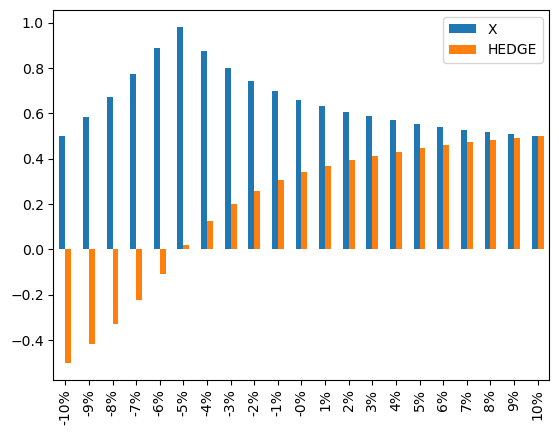

In [10]:
wgts.plot(kind = 'bar')

<Axes: >

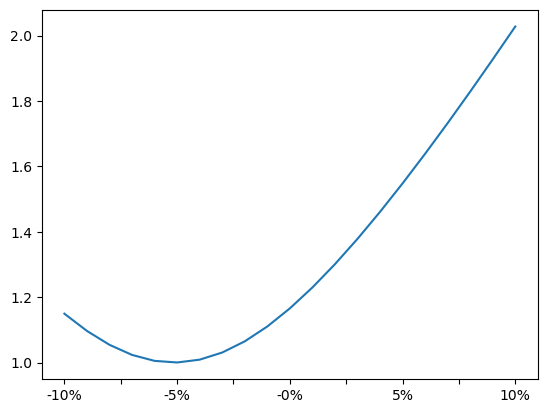

In [11]:
sharpes.plot()